Mounted at /content/drive
Found 1133 images belonging to 2 classes.
Found 282 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 369s 10s/step - accuracy: 0.6604 - loss: 0.6048 - val_accuracy: 0.8191 - val_loss: 0.4111
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 620ms/step - accuracy: 0.8763 - loss: 0.3675 - val_accuracy: 0.9255 - val_loss: 0.2633
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 547ms/step - accuracy: 0.9499 - loss: 0.2279 - val_accuracy: 0.9645 - val_loss: 0.1655
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 572ms/step - accuracy: 0.9652 - loss: 0.1473 - val_accuracy: 0.9610 - val_loss: 0.1359
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 551ms/step - accuracy: 0.9799 - loss: 0.0853 - val_accuracy: 0.9787 - val_loss: 0.0830


✅ H5 model saved: /content/drive/MyDrive/ML_WSSV/WSSV/Trained_Model/CrustaScope_model.h5
🔄 Converting to TFLite Float32...
Saved artifact at '/tmp/tmpcci7tyeq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133802527266896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802527268048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802527268432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802527267664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802527266704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802527268240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802527268624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802527269392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133802527269008: TensorSpec(sha

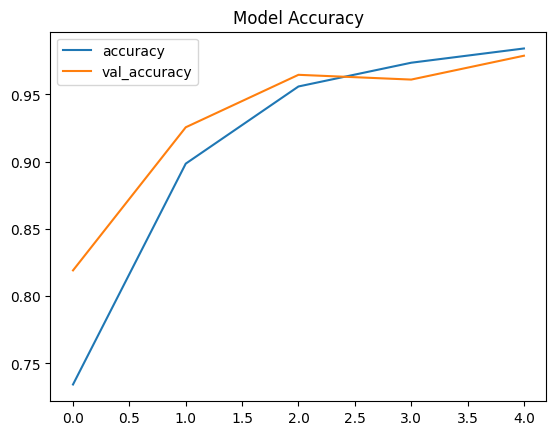

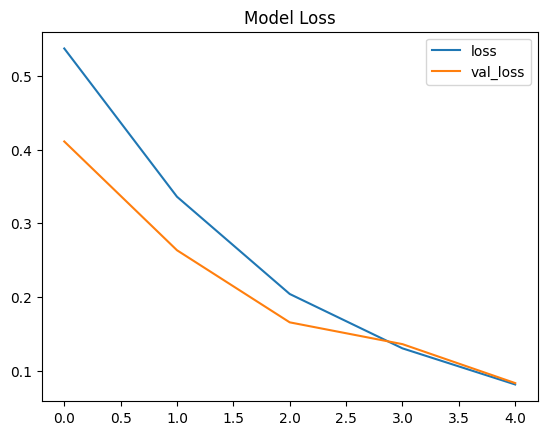

9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 889ms/step
===== Validation Metrics =====
Accuracy:  0.5508
Precision: 0.9734
Recall:    0.9946
F1 Score:  0.9839
AUC-ROC:   0.9981


In [ ]:
# =========================================================
# Mount Google Drive
# =========================================================

# Import Google Drive interface from Google Colab
# This allows the notebook to access files stored in your Google Drive
from google.colab import drive

# Connect Google Drive so datasets and trained models can be read and saved
drive.mount('/content/drive')


# =========================================================
# Import Required Libraries
# =========================================================

# OS library helps work with folders and file paths
import os

# NumPy is used for numerical calculations and handling arrays
import numpy as np

# Pandas is used to organize training results and generate graphs
import pandas as pd

# Matplotlib library is used to visualize results such as training accuracy and loss
import matplotlib.pyplot as plt

# TensorFlow is the main deep learning framework used to build and train the AI model
import tensorflow as tf

# ImageDataGenerator loads images directly from folders and prepares them for training
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Import neural network layers used to construct the CrustaScope architecture
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input, Multiply, Reshape

# Model class allows combining layers into a complete neural network
from tensorflow.keras.models import Model

# Adam optimizer adjusts model weights during training to reduce prediction errors
from tensorflow.keras.optimizers import Adam

# MobileNetV2 is used as the backbone architecture for feature extraction
# It is a lightweight but powerful CNN trained on millions of images
from tensorflow.keras.applications import MobileNetV2

# Swish activation function improves gradient flow and learning stability
from tensorflow.keras.activations import swish

# Metrics used to evaluate model performance beyond accuracy
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score


# =========================================================
# Dataset Paths
# =========================================================

# Main dataset folder stored in Google Drive
base_dir = '/content/drive/MyDrive/ML_WSSV/WSSV/dataset/Augmented_data'

# Folder containing training images
# These images teach the AI model how Healthy and WSSV shrimp look
train_dir = os.path.join(base_dir, 'train')

# Folder containing validation images
# These images are used to test model performance during training
val_dir = os.path.join(base_dir, 'validation_data')


# File path where the trained Keras model will be saved
model_h5_path = '/content/drive/MyDrive/ML_WSSV/WSSV/Trained_Model/CrustaScope_model.h5'

# File path where TensorFlow Lite model will be saved
# This version will be used on Raspberry Pi for real-time shrimp monitoring
model_tflite_path = '/content/drive/MyDrive/ML_WSSV/WSSV/Trained_Model/CrustaScope_model_float32.tflite'


# =========================================================
# Data Generators
# =========================================================

# ImageDataGenerator automatically loads images and normalizes pixel values
# Pixel values are converted from 0–255 range into 0–1 range
# This normalization helps the neural network train more efficiently
train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(

    # Training images directory
    train_dir,

    # Resize images to 224x224 pixels to match MobileNetV2 input size
    target_size=(224, 224),

    # Number of images processed in each training batch
    batch_size=32,

    # Binary classification because there are only two classes
    class_mode='binary'
)

# Validation generator evaluates model performance after each epoch
val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(

    val_dir,

    target_size=(224, 224),

    batch_size=32,

    class_mode='binary',

    # Disable shuffle so predictions match label order during evaluation
    shuffle=False
)


# =========================================================
# Squeeze-and-Excitation Block
# =========================================================

# This block improves the model's ability to focus on important features
# It learns which channels (features) are more important for classification

def se_block(input_tensor, ratio=8):

    # Determine the number of channels in the feature map
    channels = input_tensor.shape[-1]

    # GlobalAveragePooling compresses spatial information
    # It summarizes each channel into a single value
    se = GlobalAveragePooling2D()(input_tensor)

    # First Dense layer reduces the number of channels
    # This creates a smaller representation of channel importance
    se = Dense(channels // ratio, activation='relu')(se)

    # Second Dense layer restores channel dimension
    # It generates weights that indicate channel importance
    se = Dense(channels, activation='sigmoid')(se)

    # Reshape the weights so they can be multiplied with feature maps
    se = Reshape((1, 1, channels))(se)

    # Multiply feature maps with learned attention weights
    # Important channels become stronger while less useful ones weaken
    return Multiply()([input_tensor, se])


# =========================================================
# Model Architecture (CrustaScope Model)
# =========================================================

def build_shrimpnetv2(input_shape=(224, 224, 3)):

    # Load MobileNetV2 pretrained on ImageNet
    # This provides strong general image feature extraction
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze backbone layers to prevent retraining
    # This reduces overfitting and speeds up training
    for layer in base.layers:
        layer.trainable = False

    # Extract feature maps from MobileNetV2
    x = base.output

    # Apply attention mechanism using SE block
    # Helps the model focus on disease-related visual features
    x = se_block(x)

    # Convert feature maps into a feature vector
    x = GlobalAveragePooling2D()(x)

    # Dense layer with Swish activation
    # Helps capture subtle visual patterns related to infection
    x = Dense(128, activation=swish)(x)

    # Dropout randomly disables neurons during training
    # This helps prevent overfitting
    x = Dropout(0.3)(x)

    # Final output layer
    # Sigmoid activation outputs probability between 0 and 1
    output = Dense(1, activation='sigmoid')(x)

    # Combine backbone and custom layers into final model
    return Model(inputs=base.input, outputs=output)


# Build the complete CrustaScope neural network
model = build_shrimpnetv2()

# Configure training settings
model.compile(

    # Adam optimizer adjusts model weights
    optimizer=Adam(learning_rate=1e-4),

    # Binary cross entropy measures classification error
    loss='binary_crossentropy',

    # Accuracy metric tracks correct predictions
    metrics=['accuracy']
)


# =========================================================
# Model Training
# =========================================================

# Train the model using training images
# Validation dataset checks how well the model generalizes
history = model.fit(train_gen, validation_data=val_gen, epochs=5)


# =========================================================
# Save Trained Model (.h5)
# =========================================================

# Save the trained model in Keras format
# This file can be used later for inference or further training
model.save(model_h5_path)

print("✅ H5 model saved:", model_h5_path)


# =========================================================
# Convert Model to TensorFlow Lite
# =========================================================

print("🔄 Converting to TFLite Float32...")

# Create a TensorFlow Lite converter from the trained Keras model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# No optimization applied so the model remains in Float32 precision
converter.optimizations = []

# Convert model to TensorFlow Lite format
tflite_model = converter.convert()

# Save the converted TFLite model file
with open(model_tflite_path, "wb") as f:
    f.write(tflite_model)

print("✅ TFLite Float32 model saved:", model_tflite_path)


# =========================================================
# Plot Training Accuracy
# =========================================================

# Display training vs validation accuracy graph
pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()

plt.title('Model Accuracy')

plt.show()


# =========================================================
# Plot Training Loss
# =========================================================

# Display training vs validation loss graph
pd.DataFrame(history.history)[['loss', 'val_loss']].plot()

plt.title('Model Loss')

plt.show()


# =========================================================
# Additional Evaluation Metrics
# =========================================================

# Reset validation generator before making predictions
val_gen.reset()

# True labels from validation dataset
y_true = val_gen.classes

# Model predicted probabilities
y_pred_prob = model.predict(val_gen)

# Convert probability values into binary predictions
y_pred = (y_pred_prob > 0.5).astype("int32")

# Calculate evaluation metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred_prob)


# Print final evaluation results
print("===== Validation Metrics =====")

print(f"Accuracy:  {np.mean(y_true == y_pred):.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall:    {recall:.4f}")

print(f"F1 Score:  {f1:.4f}")

print(f"AUC-ROC:   {auc:.4f}")